# CURE-TSR: Training and Evaluation
CNN-based traffic sign recognition on the CURE-TSR dataset.

**Files merged:** `utils.py` · `models.py` · `logger.py` · `train.py`


## 1. Imports

In [1]:
import random
import os
import shutil
import time
import numpy as np

import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim
import torch.utils.data
import torch.utils.data.distributed
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from PIL import Image
try:
    import accimage
except ImportError:
    accimage = None

# TensorFlow logger (optional — set debug=1 below to skip)
try:
    import tensorflow as tf
    import scipy.misc
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False
    print("TensorFlow not found — logging will be skipped (debug mode forced).")


TensorFlow not found — logging will be skipped (debug mode forced).


## 2. Configuration
Set your dataset path and hyperparameters here instead of command-line arguments.

In [2]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_DIR      = "/storage/ice1/shared/d-pace_community/makerspace-datasets/AVs/CURE-TSR"  # <-- update this


# ── Training hyperparameters ─────────────────────────────────────────────────
BATCH_SIZE    = 256
EPOCHS        = 80
START_EPOCH   = 0
LR            = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 1e-4
WORKERS       = 4
PRINT_FREQ    = 10
RESUME        = ''          # path to checkpoint, or '' to start fresh
EVALUATE_ONLY = False       # True = skip training, just run evaluation

# ── Misc ──────────────────────────────────────────────────────────────────────
DEBUG         = True        # True = skip disk logging / checkpoint saving
SAVE_DIR      = 'CNN_iter'


## 3. Dataset Utilities (`utils.py`)

In [29]:
import os

def _is_tensor_image(img):
    return torch.is_tensor(img) and img.ndimension() == 3


def _is_pil_image(img):
    if accimage is not None:
        return isinstance(img, (Image.Image, accimage.Image))
    return isinstance(img, Image.Image)


def pil_loader(path):
    with open(path, 'rb') as f:
        with Image.open(f) as img:
            return img.convert('RGB')


def standardization(tensor):
    if not _is_tensor_image(tensor):
        raise TypeError('Tensor is not a torch image.')
    for t in tensor:
        t.sub_(t.mean()).div_(t.std() + (1e-8))
    return tensor


def l2normalize(tensor):
    if not _is_tensor_image(tensor):
        raise TypeError('Tensor is not a torch image.')
    tensor = tensor.mul(255)
    return tensor / torch.norm(tensor)


def make_dataset(traindir):
    imgs = []
    for fname in sorted(os.listdir(traindir)):
        target = int(fname[3:5]) - 1
        path   = os.path.join(traindir, fname)
        imgs.append((path, target))
    return imgs


class CURETSRDataset(torch.utils.data.Dataset):
    def __init__(self, traindir, transform=None, target_transform=None,
                 loader=pil_loader):
        self.traindir         = traindir
        self.imgs             = make_dataset(traindir)
        self.transform        = transform
        self.target_transform = target_transform
        self.loader           = loader

    def __getitem__(self, index):
        path, target = self.imgs[index]
        img = self.loader(path)
        if self.transform        is not None: img    = self.transform(img)
        if self.target_transform is not None: target = self.target_transform(target)
        return img, target

    def __len__(self):
        return len(self.imgs)


## 4. Model Definitions (`models.py`)

In [30]:
class Net(nn.Module):
    """Small CNN: two conv layers → three FC layers → 14-class output."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16 * 4 * 4, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, 14)

    def forward(self, x):
        import torch.nn.functional as F
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class SoftmaxClassifier(nn.Module):
    """Baseline linear classifier (28×28×3 → 14 classes)."""
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(28 * 28 * 3, 14, bias=False)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                m.weight.data.normal_().mul_(0.005)

    def forward(self, x):
        return self.fc(x.view(-1, 28 * 28 * 3))


## 5. TensorBoard Logger (`logger.py`)

In [31]:
try:
    from io import BytesIO

    class Logger:
        """TensorFlow 1.x summary writer. Only active when TF_AVAILABLE=True."""

        def __init__(self, log_dir):
            self.writer = tf.summary.FileWriter(log_dir)

        def scalar_summary(self, tag, value, step):
            summary = tf.Summary(value=[tf.Summary.Value(tag=tag, simple_value=value)])
            self.writer.add_summary(summary, step)

        def image_summary(self, tag, images, step):
            img_summaries = []
            for i, img in enumerate(images):
                s = BytesIO()
                scipy.misc.toimage(img).save(s, format='png')
                img_sum = tf.Summary.Image(
                    encoded_image_string=s.getvalue(),
                    height=img.shape[0], width=img.shape[1])
                img_summaries.append(
                    tf.Summary.Value(tag=f'{tag}/{i}', image=img_sum))
            self.writer.add_summary(tf.Summary(value=img_summaries), step)

        def histo_summary(self, tag, values, step, bins=1000):
            counts, bin_edges = np.histogram(values, bins=bins)
            hist = tf.HistogramProto()
            hist.min, hist.max = float(np.min(values)), float(np.max(values))
            hist.num = int(np.prod(values.shape))
            hist.sum = float(np.sum(values))
            hist.sum_squares = float(np.sum(values ** 2))
            for edge in bin_edges[1:]: hist.bucket_limit.append(edge)
            for c in counts:           hist.bucket.append(c)
            self.writer.add_summary(
                tf.Summary(value=[tf.Summary.Value(tag=tag, histo=hist)]), step)
            self.writer.flush()

except NameError:
    class Logger:
        """No-op logger used when TensorFlow is unavailable."""
        def __init__(self, *a, **kw): pass
        def scalar_summary(self, *a, **kw): pass
        def image_summary(self, *a, **kw): pass
        def histo_summary(self, *a, **kw): pass


## 6. Training Helpers (`train.py`)

In [32]:
class AverageMeter:
    """Tracks and accumulates a running average."""
    def __init__(self): self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0

    def update(self, val, n=1):
        self.val    = val
        self.sum   += val * n
        self.count += n
        self.avg    = self.sum / self.count


def adjust_learning_rate(optimizer, epoch, base_lr):
    lr = base_lr * (0.1 ** (epoch // 30))
    for pg in optimizer.param_groups:
        pg['lr'] = lr


def accuracy(output, target, topk=(1,)):
    maxk       = max(topk)
    batch_size = target.size(0)
    _, pred    = output.topk(maxk, 1, True, True)
    pred       = pred.t()
    correct    = pred.eq(target.view(1, -1).expand_as(pred))
    return [
        correct[:k].reshape(-1).float().sum(0, keepdim=True).mul_(100.0 / batch_size)
        for k in topk
    ]


def save_checkpoint(state, is_best, checkpointdir):
    full      = os.path.join(checkpointdir, 'checkpoint.pth.tar')
    full_best = os.path.join(checkpointdir, 'model_best.pth.tar')
    torch.save(state, full)
    if is_best:
        shutil.copyfile(full, full_best)


## 7. Build Data Loaders

In [33]:
traindir = os.path.join(DATA_DIR, 'Real_Train/ChallengeFree')
testdir  = os.path.join(DATA_DIR, 'Real_Test/ChallengeFree')

tfm = transforms.Compose([
    transforms.Resize([28, 28]),
    transforms.ToTensor(),
    l2normalize,
    standardization,
])

train_dataset = CURETSRDataset(traindir, transform=tfm)
test_dataset  = CURETSRDataset(testdir,  transform=tfm)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=WORKERS, pin_memory=True)

print(f"Train samples: {len(train_dataset)}  |  Test samples: {len(test_dataset)}")


Train samples: 7292  |  Test samples: 3334


## 8. Model, Loss & Optimizer

In [34]:
model     = torch.nn.DataParallel(Net()).cuda()
criterion = nn.CrossEntropyLoss().cuda()
optimizer = torch.optim.SGD(model.parameters(), LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
print(f"Model: {model.__class__.__name__}  |  Parameters: "
      f"{sum(p.numel() for p in model.parameters()):,}")


Model: DataParallel  |  Parameters: 45,066


## 9. (Optional) Resume from Checkpoint

In [35]:
best_prec1 = 0

if RESUME:
    if os.path.isfile(RESUME):
        print(f"=> loading checkpoint '{RESUME}'")
        ckpt = torch.load(RESUME)
        START_EPOCH = ckpt['epoch']
        best_prec1  = ckpt['best_prec1']
        model.load_state_dict(ckpt['state_dict'])
        optimizer.load_state_dict(ckpt['optimizer'])
        print(f"=> loaded checkpoint (epoch {ckpt['epoch']}, best_prec1={best_prec1:.3f})")
    else:
        print(f"=> no checkpoint found at '{RESUME}'")


## 10. Train & Evaluate Functions

In [37]:
def train_one_epoch(loader, model, criterion, optimizer, epoch):
    batch_time = AverageMeter(); data_time = AverageMeter()
    losses = AverageMeter(); top1 = AverageMeter(); top5 = AverageMeter()
    model.train()
    end = time.time()

    for i, (inputs, targets) in enumerate(loader):
        data_time.update(time.time() - end)
        targets   = targets.cuda()
        inputs_v  = torch.autograd.Variable(inputs)
        targets_v = torch.autograd.Variable(targets)

        output = model(inputs_v)
        loss   = criterion(output, targets_v)
        prec1, prec5 = accuracy(output.data, targets, topk=(1, 5))

        losses.update(loss.data,   inputs.size(0))
        top1.update(prec1[0],      inputs.size(0))
        top5.update(prec5[0],      inputs.size(0))

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        batch_time.update(time.time() - end); end = time.time()

        if i % PRINT_FREQ == 0:
            print(f'Epoch [{epoch}][{i}/{len(loader)}]  '
                  f'Time {batch_time.val:.3f} ({batch_time.avg:.3f})  '
                  f'Loss {losses.val:.4f} ({losses.avg:.4f})  '
                  f'Prec@1 {top1.val:.3f} ({top1.avg:.3f})  '
                  f'Prec@5 {top5.val:.3f} ({top5.avg:.3f})')

    return losses.avg, top1.avg, top5.avg


def evaluate(loader, model, criterion):
    batch_time = AverageMeter()
    losses = AverageMeter(); top1 = AverageMeter(); top5 = AverageMeter()
    model.eval()
    end = time.time()

    for i, (inputs, targets) in enumerate(loader):
        targets = targets.cuda()
        with torch.no_grad():
            output = model(inputs)
            loss   = criterion(output, targets)

        prec1, prec5 = accuracy(output.data, targets, topk=(1, 5))
        losses.update(loss.data,  inputs.size(0))
        top1.update(prec1[0],     inputs.size(0))
        top5.update(prec5[0],     inputs.size(0))

        batch_time.update(time.time() - end); end = time.time()

        if i % PRINT_FREQ == 0:
            print(f'Test [{i}/{len(loader)}]  '
                  f'Time {batch_time.val:.3f} ({batch_time.avg:.3f})  '
                  f'Loss {losses.val:.4f} ({losses.avg:.4f})  '
                  f'Prec@1 {top1.val:.3f} ({top1.avg:.3f})  '
                  f'Prec@5 {top5.val:.3f} ({top5.avg:.3f})')

    print(f' * Prec@1 {top1.avg:.3f}  Prec@5 {top5.avg:.3f}')
    return losses.avg, top1.avg, top5.avg


## 11. Training Loop

In [38]:
if EVALUATE_ONLY:
    evaluate(test_loader, model, criterion)
else:
    # Set up logging / checkpointing (skipped in debug mode)
    checkpointdir = os.path.join('./checkpoints', SAVE_DIR)
    if not DEBUG:
        
        os.makedirs(checkpointdir, exist_ok=True)
        logger = Logger(os.path.join('./logs', SAVE_DIR))
        print(f'Checkpoints → {checkpointdir}')

    cudnn.benchmark = True
    timestart  = time.time()
    best_epoch = START_EPOCH

    for epoch in range(START_EPOCH, EPOCHS):
        adjust_learning_rate(optimizer, epoch, LR)

        print(f'\n*** Epoch {epoch} — Training ***')
        train_one_epoch(train_loader, model, criterion, optimizer, epoch)

        print(f'\n*** Epoch {epoch} — Evaluation ***')
        test_loss, test_prec1, _ = evaluate(test_loader, model, criterion)

        is_best    = test_prec1 > best_prec1
        best_prec1 = max(test_prec1, best_prec1)
        if is_best:
            best_epoch = epoch + 1

        if not DEBUG:
            for tag, val in [('Testing loss', test_loss),
                             ('Testing Accuracy', test_prec1)]:
                logger.scalar_summary(tag, val, epoch + 1)

            save_checkpoint({
                'epoch':      epoch + 1,
                'state_dict': model.state_dict(),
                'best_prec1': best_prec1,
                'last_prec1': test_prec1,
                'optimizer':  optimizer.state_dict(),
            }, is_best, checkpointdir)

    print(f'\nBest epoch : {best_epoch}')
    print(f'Total time : {time.time() - timestart:.4f}s')



*** Epoch 0 — Training ***
Epoch [0][0/29]  Time 2.223 (2.223)  Loss 2.6228 (2.6228)  Prec@1 13.281 (13.281)  Prec@5 52.734 (52.734)
Epoch [0][10/29]  Time 0.066 (0.528)  Loss 1.9057 (2.3112)  Prec@1 33.984 (30.646)  Prec@5 90.234 (76.882)
Epoch [0][20/29]  Time 1.216 (0.484)  Loss 1.1853 (1.9542)  Prec@1 57.812 (39.230)  Prec@5 93.750 (82.478)

*** Epoch 0 — Evaluation ***
Test [0/14]  Time 1.762 (1.762)  Loss 0.5044 (0.5044)  Prec@1 94.141 (94.141)  Prec@5 98.828 (98.828)
Test [10/14]  Time 0.171 (0.458)  Loss 0.0015 (1.9313)  Prec@1 100.000 (55.611)  Prec@5 100.000 (90.838)
 * Prec@1 62.507  Prec@5 92.262

*** Epoch 1 — Training ***
Epoch [1][0/29]  Time 0.576 (0.576)  Loss 0.6631 (0.6631)  Prec@1 80.469 (80.469)  Prec@5 98.438 (98.438)
Epoch [1][10/29]  Time 0.013 (0.130)  Loss 0.4084 (0.5339)  Prec@1 91.406 (84.339)  Prec@5 100.000 (98.118)
Epoch [1][20/29]  Time 0.374 (0.128)  Loss 0.2500 (0.4253)  Prec@1 92.188 (87.463)  Prec@5 99.609 (98.698)

*** Epoch 1 — Evaluation ***
Test

Epoch [13][10/29]  Time 0.013 (0.137)  Loss 0.0000 (0.0006)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [13][20/29]  Time 0.388 (0.133)  Loss 0.0001 (0.0004)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 13 — Evaluation ***
Test [0/14]  Time 0.582 (0.582)  Loss 0.1165 (0.1165)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.023 (0.134)  Loss 0.0014 (0.8094)  Prec@1 100.000 (89.062)  Prec@5 100.000 (96.342)
 * Prec@1 90.762  Prec@5 96.911

*** Epoch 14 — Training ***
Epoch [14][0/29]  Time 0.582 (0.582)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [14][10/29]  Time 0.016 (0.137)  Loss 0.0000 (0.0002)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [14][20/29]  Time 0.381 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 14 — Evaluation ***
Test [0/14]  Time 0.576 (0.576)  Loss 0.1188 (0.1188)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

Epoch [26][10/29]  Time 0.015 (0.137)  Loss 0.0003 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [26][20/29]  Time 0.382 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 26 — Evaluation ***
Test [0/14]  Time 0.573 (0.573)  Loss 0.1242 (0.1242)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.023 (0.135)  Loss 0.0008 (0.8779)  Prec@1 100.000 (88.778)  Prec@5 100.000 (95.952)
 * Prec@1 90.522  Prec@5 96.581

*** Epoch 27 — Training ***
Epoch [27][0/29]  Time 0.602 (0.602)  Loss 0.0002 (0.0002)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [27][10/29]  Time 0.024 (0.135)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [27][20/29]  Time 0.382 (0.132)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 27 — Evaluation ***
Test [0/14]  Time 0.586 (0.586)  Loss 0.1250 (0.1250)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

Epoch [39][10/29]  Time 0.018 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [39][20/29]  Time 0.384 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 39 — Evaluation ***
Test [0/14]  Time 0.577 (0.577)  Loss 0.1233 (0.1233)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.023 (0.134)  Loss 0.0007 (0.8792)  Prec@1 100.000 (88.672)  Prec@5 100.000 (95.845)
 * Prec@1 90.432  Prec@5 96.491

*** Epoch 40 — Training ***
Epoch [40][0/29]  Time 0.573 (0.573)  Loss 0.0000 (0.0000)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [40][10/29]  Time 0.018 (0.134)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [40][20/29]  Time 0.382 (0.133)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 40 — Evaluation ***
Test [0/14]  Time 0.590 (0.590)  Loss 0.1232 (0.1232)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

Epoch [52][10/29]  Time 0.014 (0.134)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [52][20/29]  Time 0.384 (0.131)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 52 — Evaluation ***
Test [0/14]  Time 0.584 (0.584)  Loss 0.1227 (0.1227)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.027 (0.138)  Loss 0.0007 (0.8785)  Prec@1 100.000 (88.601)  Prec@5 100.000 (95.845)
 * Prec@1 90.372  Prec@5 96.491

*** Epoch 53 — Training ***
Epoch [53][0/29]  Time 0.570 (0.570)  Loss 0.0000 (0.0000)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [53][10/29]  Time 0.017 (0.134)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [53][20/29]  Time 0.384 (0.131)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 53 — Evaluation ***
Test [0/14]  Time 0.577 (0.577)  Loss 0.1227 (0.1227)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

Epoch [65][10/29]  Time 0.015 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [65][20/29]  Time 0.381 (0.132)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 65 — Evaluation ***
Test [0/14]  Time 0.583 (0.583)  Loss 0.1224 (0.1224)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.020 (0.133)  Loss 0.0007 (0.8780)  Prec@1 100.000 (88.601)  Prec@5 100.000 (95.845)
 * Prec@1 90.372  Prec@5 96.491

*** Epoch 66 — Training ***
Epoch [66][0/29]  Time 0.582 (0.582)  Loss 0.0000 (0.0000)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [66][10/29]  Time 0.016 (0.133)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [66][20/29]  Time 0.424 (0.133)  Loss 0.0002 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 66 — Evaluation ***
Test [0/14]  Time 0.581 (0.581)  Loss 0.1223 (0.1223)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

Epoch [78][10/29]  Time 0.011 (0.133)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [78][20/29]  Time 0.377 (0.130)  Loss 0.0000 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 78 — Evaluation ***
Test [0/14]  Time 0.579 (0.579)  Loss 0.1223 (0.1223)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/14]  Time 0.025 (0.134)  Loss 0.0007 (0.8779)  Prec@1 100.000 (88.601)  Prec@5 100.000 (95.845)
 * Prec@1 90.372  Prec@5 96.491

*** Epoch 79 — Training ***
Epoch [79][0/29]  Time 0.581 (0.581)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [79][10/29]  Time 0.019 (0.133)  Loss 0.0001 (0.0000)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)
Epoch [79][20/29]  Time 0.380 (0.130)  Loss 0.0001 (0.0001)  Prec@1 100.000 (100.000)  Prec@5 100.000 (100.000)

*** Epoch 79 — Evaluation ***
Test [0/14]  Time 0.575 (0.575)  Loss 0.1223 (0.1223)  Prec@1 98.828 (98.828)  Prec@5 99.609 (99.609)
Test [10/

In [40]:
import torch
import torch.nn.functional as F
import numpy as np

def collect_logits(loader, model):
    """Run the test set through the model and collect raw logits + true labels."""
    model.eval()
    all_logits, all_labels = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            logits = model(inputs)          # raw, un-softmaxed
            all_logits.append(logits.cpu())
            all_labels.append(targets.cpu())

    return torch.cat(all_logits), torch.cat(all_labels)

logits, labels = collect_logits(test_loader, model)
print(f"Logits shape: {logits.shape}  |  Labels shape: {labels.shape}")

Logits shape: torch.Size([3334, 14])  |  Labels shape: torch.Size([3334])


In [41]:
import matplotlib.pyplot as plt

def reliability_diagram(logits, labels, n_bins=10, title="Reliability diagram", ax=None):
    """
    Plot a reliability diagram and return the Expected Calibration Error (ECE).
    Works with raw logits — converts to probabilities internally.
    """
    probs      = F.softmax(logits, dim=1)
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    conf_np = confidences.numpy()
    acc_np  = accuracies.numpy().astype(float)

    bin_edges  = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_edges[:-1]
    bin_uppers = bin_edges[1:]

    ece        = 0.0
    bin_accs   = []
    bin_confs  = []
    bin_counts = []

    for lo, hi in zip(bin_lowers, bin_uppers):
        mask = (conf_np >= lo) & (conf_np < hi)
        n    = mask.sum()
        bin_counts.append(n)
        if n > 0:
            bin_acc  = acc_np[mask].mean()
            bin_conf = conf_np[mask].mean()
            ece     += (n / len(conf_np)) * abs(bin_acc - bin_conf)
        else:
            bin_acc = bin_conf = 0.0
        bin_accs.append(bin_acc)
        bin_confs.append(bin_conf)

    # ── Plot ──────────────────────────────────────────────────────────────────
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))

    bin_mids = (bin_lowers + bin_uppers) / 2
    ax.bar(bin_mids, bin_accs,   width=1/n_bins, align='center',
           alpha=0.7, label='Accuracy', color='steelblue', edgecolor='white')
    ax.bar(bin_mids, bin_confs,  width=1/n_bins, align='center',
           alpha=0.3, label='Gap',      color='tomato',    edgecolor='white')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'{title}\nECE = {ece:.4f}')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    return ece, bin_accs, bin_confs

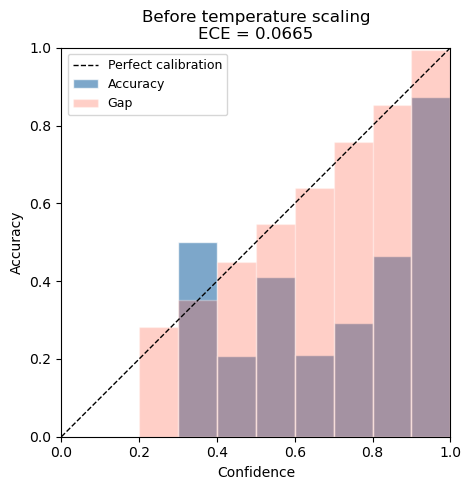

ECE before: 0.0665


In [42]:
fig, ax = plt.subplots(figsize=(5, 5))
ece_before, _, _ = reliability_diagram(logits, labels, title="Before temperature scaling", ax=ax)
plt.tight_layout()
plt.savefig("reliability_before.png", dpi=150)
plt.show()
print(f"ECE before: {ece_before:.4f}")

In [43]:
class TemperatureScaler(torch.nn.Module):
    """
    Wraps a model and divides all logits by a learnable scalar T.
    T > 1 → softer (more uncertain) predictions  (typical for overconfident models)
    T < 1 → sharper predictions
    """
    def __init__(self):
        super().__init__()
        self.temperature = torch.nn.Parameter(torch.ones(1))  # init T = 1.0

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, logits, labels, lr=0.01, max_iter=100):
        """Optimize T by minimizing NLL on the validation logits."""
        optimizer = torch.optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)
        nll = torch.nn.CrossEntropyLoss()

        def closure():
            optimizer.zero_grad()
            loss = nll(self(logits), labels)
            loss.backward()
            return loss

        optimizer.step(closure)
        print(f"Optimal temperature: {self.temperature.item():.4f}")
        return self


scaler = TemperatureScaler()
scaler.fit(logits, labels)

Optimal temperature: 1.5454


TemperatureScaler()

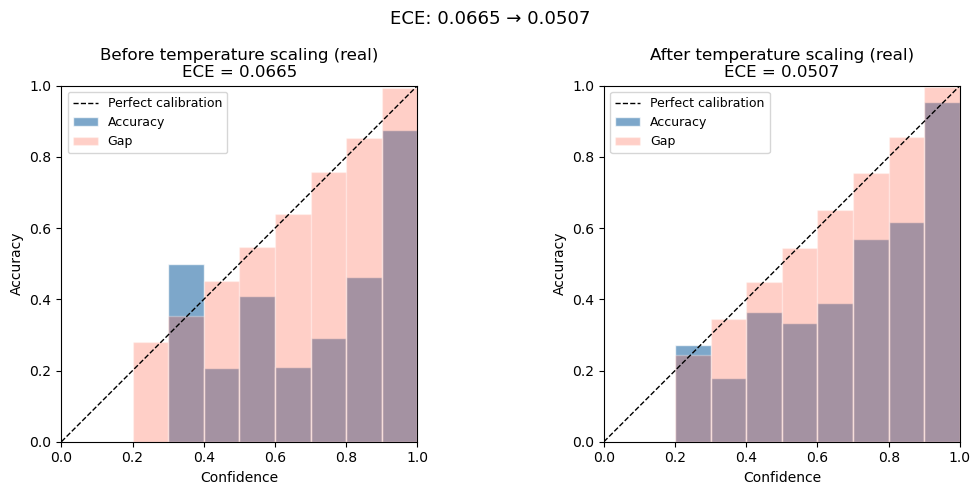

In [44]:
with torch.no_grad():
    logits_scaled = scaler(logits)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ece_before, _, _ = reliability_diagram(logits,        labels, title="Before temperature scaling (real)", ax=axes[0])
ece_after,  _, _ = reliability_diagram(logits_scaled, labels, title="After temperature scaling (real)",  ax=axes[1])

plt.suptitle(f"ECE: {ece_before:.4f} → {ece_after:.4f}", fontsize=13)
plt.tight_layout()
plt.savefig("reliability_comparison.png", dpi=150)
plt.show()

In [45]:
# Check raw top-1 accuracy first
probs = torch.softmax(logits, dim=1)
preds = probs.argmax(dim=1)
acc = (preds == labels).float().mean()
print(f"Top-1 accuracy: {acc:.4f}")

# Check confidence distribution
confidences = probs.max(dim=1).values
print(f"Mean confidence: {confidences.mean():.4f}")
print(f"% predictions above 0.9 confidence: {(confidences > 0.9).float().mean():.4f}")

Top-1 accuracy: 0.9037
Mean confidence: 0.9717
% predictions above 0.9 confidence: 0.9244


In [46]:
import os

def make_dataset(traindir):
    imgs = []
    # walk through the root, its dirs, and its files
    for root, dirs, files in os.walk(traindir):
        for fname in sorted(files):
            # 1. Ensure we only grab image files
            if fname.lower().endswith(('.bmp', '.jpg', '.jpeg')):
                try:
                    # 2. Extract target from filename (e.g., 'img01_...')
                    target = int(fname[3:5]) - 1
                    path = os.path.join(root, fname)
                    imgs.append((path, target))
                except ValueError:
                    # Skips files that don't have digits at index 3:5
                    continue
    print(len(imgs))
    return imgs

In [47]:
unreal_testdir  = os.path.join(DATA_DIR, 'Unreal_Test')

tfm = transforms.Compose([
    transforms.Resize([28, 28]),
    transforms.ToTensor(),
    l2normalize,
    standardization,
])

unreal_test_dataset  = CURETSRDataset(unreal_testdir,  transform=tfm)

unreal_test_loader  = DataLoader(unreal_test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=WORKERS, pin_memory=True)

print(f"Test samples: {len(unreal_test_dataset)}")

459760
Test samples: 459760


In [49]:
import torch
import torch.nn.functional as F
import numpy as np

from tqdm import tqdm # You might need to pip install tqdm

def collect_logits(loader, model):
    model.eval()
    all_logits, all_labels = [], []
    device = next(model.parameters()).device # Automatically detect where the model is

    with torch.no_grad():
        # Wrap loader in tqdm for a progress bar
        for inputs, targets in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(device)
            logits = model(inputs)
            all_logits.append(logits.cpu())
            all_labels.append(targets.cpu())

    return torch.cat(all_logits), torch.cat(all_labels)

logits, labels = collect_logits(unreal_test_loader, model)
print(f"Logits shape: {logits.shape}  |  Labels shape: {labels.shape}")

Evaluating: 100%|██████████| 1796/1796 [11:50<00:00,  2.53it/s]

Logits shape: torch.Size([459760, 14])  |  Labels shape: torch.Size([459760])


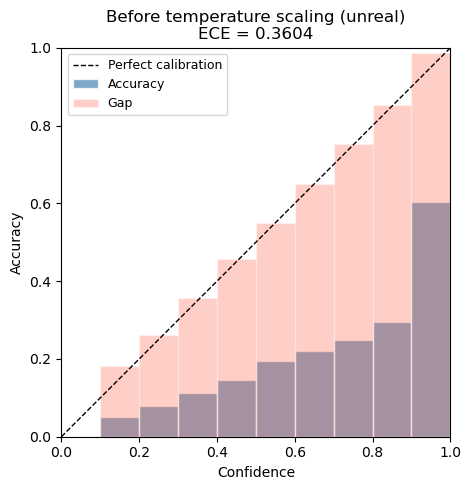

ECE before: 0.3604


In [53]:
fig, ax = plt.subplots(figsize=(5, 5))
ece_before, _, _ = reliability_diagram(logits, labels, title="Before temperature scaling (unreal)", ax=ax)
plt.tight_layout()
plt.savefig("unreal_ reliability_before.png", dpi=150)
plt.show()
print(f"ECE before: {ece_before:.4f}")

In [54]:
with torch.no_grad():
    unreal_logits_real_T   = scaler(logits)    # training scaling applied to unreal logits

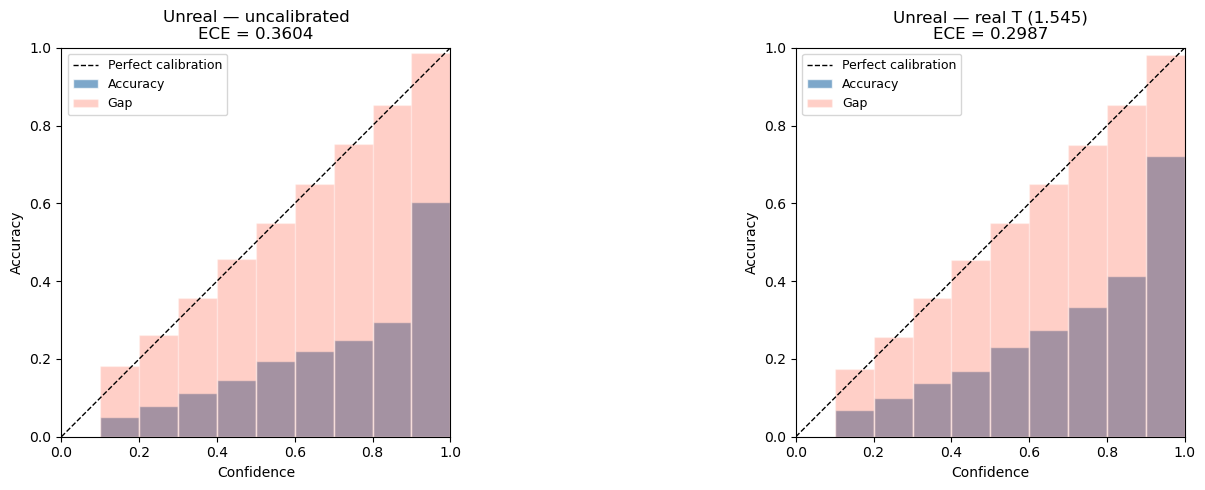

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

reliability_diagram(logits,                  labels, title="Unreal — uncalibrated",            ax=axes[0])
reliability_diagram(unreal_logits_real_T,    labels, title=f"Unreal — real T ({scaler.temperature.item():.3f})",   ax=axes[1])


plt.tight_layout()
plt.show()
